In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import random
device = "cuda" if torch.cuda.is_available() else "cpu"
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [ ]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2024-10-24 20:03:23--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [              <=>   ] 201.24M  52.9MB/s    in 3.9s    

2024-10-24 20:03:27 (51.9 MB/s) - ‘data.txt.zip’ saved [211011981]



In [ ]:
df = pd.read_csv('data.txt.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Мы вывели кусок данных, чтобы понять, насколько они пригодны для работы без изменений. Здесь ясно, что сомнительно дальше с такими данными работать, потому что как минимум есть отрицательные значения, которые не отмасштабированы, кроме того еще сразу бросается в глаза совсем разная размерность, где-то видим реально большие числа, а где-то 0.075. Ясно, что будем скейлить.

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
train_size = 463715
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

In [ ]:
X_train[: ,0].shape
y_train.shape

(463715,)

In [ ]:
y_train_mean = np.mean(y_train)
y_train_std = np.std(y_train)

## Задание 0. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Для самого первого бейзлайна обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями
2. Обучите StandertScaler и предобработайте ваши данные. В следующих заданиях можете использовать другой scaler или вообще отказаться от него


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train2 = scaler.transform(X_train)
X_test2 = scaler.transform(X_test)

In [ ]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
set_random_seed(42)

In [ ]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=10).fit(X_train2, y_train)
y_train_pred = model.predict(X_train2)
y_test_pred = model.predict(X_test2)
rmse_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2))
rmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
rmse_train, rmse_test

(9.552822974530542, 9.510161842816515)

Лучшая константа для RMSE это среднее, посчитаем значение метрики при нем

In [ ]:
best_rmse_metric = np.sqrt(np.mean((y_test - np.mean(y_train)) ** 2))
best_rmse_metric

10.85246390513634

## Задание 1. (максимум 10 баллов)

Закрепите свои знания о том, как pytorch работает с обратным распространением ошибки, проделав следующие шаги:

1. Создайте модель линейной регрессии, которая будет состоять только из одного Linear слоя.
2. Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки pytorch. Для подсчета градиента воспользуйтесь методом backward.
3. Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
4. Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача - убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [ ]:
X_train2 = torch.from_numpy(X_train2.copy())
y_train = torch.from_numpy(y_train.copy())
X_test2 = torch.from_numpy(X_test2.copy())
y_test = torch.from_numpy(y_test.copy())

In [ ]:
X_train2 = X_train2.float()
y_train = y_train.float()
X_test2 = X_test2.float()
y_test = y_test.float()

In [ ]:
set_random_seed(42)
simple_model = nn.Linear(90, 1)
simple_model.to(device)

Linear(in_features=90, out_features=1, bias=True)

In [ ]:
lr = 0.05
loss_train = np.array([])
loss_test_ar = np.array([])
for epoch in range(10):
    y_pred = simple_model(X_train2[:1000].to(device))
    loss = torch.mean((y_pred - y_train[:1000].to(device)) ** 2)
    loss.backward()

    with torch.no_grad():
        y_test_pred = simple_model(X_test2[:1000].to(device))
        loss_test = torch.mean((y_test_pred - y_test[:1000].to(device)) ** 2)
        loss_train = np.append(loss_train, np.sqrt(loss.cpu().detach().numpy()))
        loss_test_ar = np.append(loss_test_ar, np.sqrt(loss_test.cpu().detach().numpy()))

    for param in simple_model.parameters():
        param.data -= lr * param.grad.data

    simple_model.zero_grad()

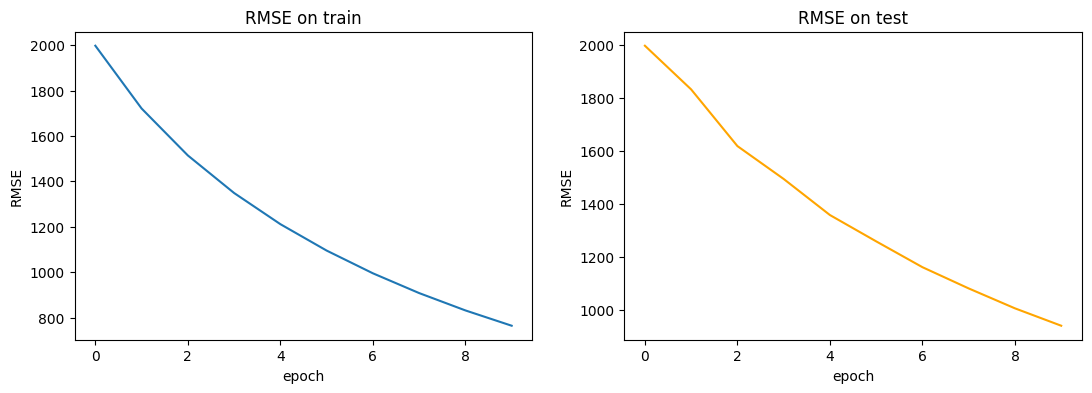

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(range(10), loss_train, label='train')
axs[1].plot(range(10), loss_test_ar, label='test', color='orange')
axs[0].set_title('RMSE on train', fontsize=12)
axs[1].set_title('RMSE on test', fontsize=12)
for ax in axs:
    ax.set_xlabel('epoch')
    ax.set_ylabel('RMSE')
plt.show()

## Задание 2. (максимум 10 баллов)

Реализуйте обучение и тестирование нейронной сети для предоставленного вам набора данных. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 9.00 $ &mdash; 4 балла
- $\text{RMSE} \le 8.90 $ &mdash; 6 баллов
- $\text{RMSE} \le 8.80 $ &mdash; 8 баллов
- $\text{RMSE} \le 8.75 $ &mdash; 10 баллов

Есть несколько правил, которых вам нужно придерживаться:

- Весь пайплайн обучения должен быть написан на PyTorch. При этом вы можете пользоваться другими библиотеками (`numpy`, `sklearn` и пр.), но только для обработки данных. То есть как угодно трансформировать данные и считать метрики с помощью этих библиотек можно, а импортировать модели из `sklearn` и выбивать с их помощью требуемое качество &mdash; нельзя. Также нельзя пользоваться библиотеками, для которых сам PyTorch является зависимостью.

- Мы никак не ограничиваем ваш выбор архитектуры модели, но скорее всего вам будет достаточно полносвязной нейронной сети.

- Для обучения запрещается использовать какие-либо иные данные, кроме обучающей выборки.

- Ансамблирование моделей запрещено.

### Полезные советы:

- Очень вряд ли, что у вас с первого раза получится выбить качество на 10 баллов, поэтому пробуйте разные архитектуры, оптимизаторы и значения гиперпараметров. В идеале при запуске каждого нового эксперимента вы должны менять что-то одно, чтобы точно знать, как этот фактор влияет на качество.

- Не забудьте, что для улучшения качества модели вам поможет **нормировка таргета**.

- Тот факт, что мы занимаемся глубинным обучением, не означает, что стоит забывать про приемы, использующиеся в классическом машинном обучении. Так что обязательно проводите исследовательский анализ данных, отрисовывайте нужные графики и не забывайте про масштабирование и подбор гиперпараметров.

- Вы наверняка столкнетесь с тем, что ваша нейронная сеть будет сильно переобучаться. Для нейросетей существуют специальные методы регуляризации, например, dropout ([статья](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) и weight decay ([блогпост](https://towardsdatascience.com/weight-decay-l2-regularization-90a9e17713cd)). Они, разумеется, реализованы в PyTorch. Попробуйте поэкспериментировать с ними.

- Если вы чего-то не знаете, не гнушайтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению в целом и по PyTorch в частности. Но не забывайте, что за скатанный код без ссылки на источник придется ответить по всей строгости!

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так!

- Пользуйтесь утилитами, которые вам предоставляет PyTorch (например, Dataset и Dataloader). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

**ОБЯЗАТЕЛЬНО** рисуйте графики зависимости лосса/метрики на обучающей и тестовой выборках в зависимости от времени обучения. Если обучение занимает относительно небольшое число эпох, то лучше рисовать зависимость от номера шага обучения, если же эпох больше, то рисуйте зависимость по эпохам. Если проверяющий не увидит такого графика для вашей лучшей модели, то он в праве снизить баллы за задание.

**ВАЖНО!** Ваше решение должно быть воспроизводимым. Если это не так, то проверяющий имеет право снизить баллы за задание. Чтобы зафиксировать random seed, воспользуйтесь функцией из предыдущего задания.



Вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. Лучше всего, если вы проверите ваши предсказания ассертом: так вы убережете себя от разных косяков, например, что вектор предсказаний состоит из всего одного числа. В любом случае, внимательно следите за тем, для каких тензоров вы считаете метрику RMSE. При случайном или намеренном введении в заблуждение проверяющие очень сильно разозлятся.

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "sample": torch.tensor(self.x[idx, :], dtype=torch.float),
            "target": self.y[idx],
        }

In [ ]:
X_train2.shape, X_test2.shape # 90 признаков

(torch.Size([463715, 90]), torch.Size([51630, 90]))

In [ ]:
set_random_seed(42)
from torch.utils.data import DataLoader

train_set = MyDataset(X_train2, y_train)
train_loader = DataLoader(train_set, shuffle=True, batch_size=1000)
test_set = MyDataset(X_test2, y_test)
test_loader = DataLoader(test_set, batch_size=32)

model = nn.Sequential(
    nn.Linear(
        90, 50
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        50, 30
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        30, 10
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
         10, 1
    )).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0)
criterion = nn.MSELoss()

In [ ]:
def train(model, optimizer, criterion, train_loader, test_loader):
    """
    params:

        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        test_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    train_losses = []
    val_losses = []
    for epoch in range(1, epochs + 1):
        train_loss = 0.0
        val_loss = 0.0

        model.train()
        for batch in tqdm(train_loader):
            x_train = batch['sample'].clone().to(device)
            y_train = batch['target'].clone().to(device)
            y_train = (y_train - y_train_mean) / y_train_std

            optimizer.zero_grad()
            y_pred_train = model(x_train).squeeze()
            loss = criterion(y_pred_train, y_train)
            loss.backward()
            optimizer.step()

            y_pred_train_inv = y_pred_train * y_train_std + y_train_mean
            y_train_inv = y_train * y_train_std + y_train_mean
            train_loss += torch.mean((y_pred_train_inv - y_train_inv) ** 2).item() * x_train.shape[0]

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss ** 0.5)
        model.eval()
        with torch.no_grad():
            for batch in tqdm(test_loader):
                x_val = batch['sample'].clone().to(device)
                y_val = batch['target'].clone().to(device)
                y_pred_test = model(x_val).squeeze() * y_train_std + y_train_mean

                val_loss += torch.mean((y_pred_test - y_val) ** 2).item() * x_val.shape[0]

            val_loss /= len(test_loader.dataset)
            val_losses.append(val_loss ** 0.5)


        clear_output()
        fig, ax = plt.subplots(1, 1, figsize=(13, 4))
        ax.plot(range(1, len(train_losses) + 1), train_losses, label='train')
        ax.plot(range(1, len(val_losses) + 1), val_losses, label='test')
        ax.set_ylabel('loss')
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(True)
        ax.set_title('RMSE on train and test depending on the epoch')

        plt.show()
        print(f'RMSE train: {train_loss ** 0.5}')
        print(f'RMSE test: {val_loss ** 0.5}')
        print(epoch)

        if val_loss ** 0.5 < 8.8:
            break
    return f'Best RMSE on test: {val_loss ** 0.5}'
    raise NotImplementedError



def test(model, criterion, test_loader):
    """
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
        rmse
    """

    predicts =  model(next(iter(test_loader))['sample'].to(device)).squeeze() * y_train_std + y_train_mean
    rmse = criterion(predicts.to(device), next(iter(test_loader))['target'].to(device)) ** 0.5

    return (rmse, predicts)



In [ ]:
set_random_seed(42)
test_loader2 = DataLoader(test_set, batch_size=X_test2.shape[0])

In [ ]:
assert test(model, criterion, test_loader2)[1].shape[0] == y_test.to(device).shape[0]

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


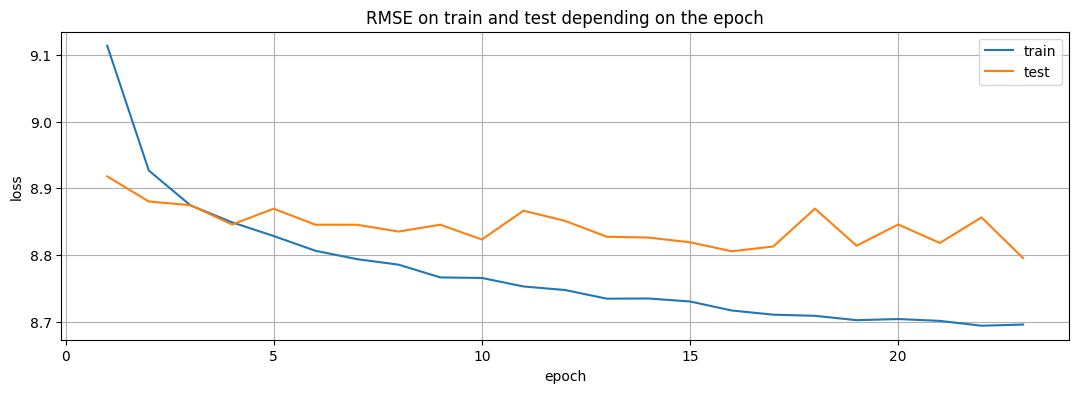

RMSE train: 8.695649013882614
RMSE test: 8.795311568607167
23


'Best RMSE on test: 8.795311568607167'

In [ ]:
set_random_seed(42)
epochs = 100
train(model, optimizer, criterion, train_loader, test_loader)

In [ ]:
rmse, predicts = test(model, criterion, test_loader2)

<ipython-input-98-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
print(f'RMSE test = {rmse.item()}')
print(f'Predicted target test: {predicts}')

RMSE test = 8.79531192779541
Predicted target test: tensor([1999.3350, 2002.7460, 2001.8724,  ..., 1997.2218, 2002.7097,
        2001.1703], device='cuda:0', grad_fn=<AddBackward0>)


## Задание 3. (0 баллов, но при невыполнении максимум за все задание &mdash; 0 баллов)

Напишите небольшой отчет о том, как вы добились полученного качества: какие средства использовали и какие эксперименты проводили. Подробно расскажите об архитектурах и значениях гиперпараметров, а также какие метрики на тесте они показывали. Чтобы отчет был зачтен, необходимо привести хотя бы 3 эксперимента.

В начале я искренне не хотела нормализовать у (зря) и мучилась, пытаясь выбить лосс так. Пробовала менять метрики (HuberLoss, L1Loss), но от них эффекта никакого как будто не было. Поменяла SGD на AdamW, и стало получше. Также работала с размером батчей (начинала с 64, пробовала меньше (16 и 32) - плохо, пробовала с 128, 256 и решила бабахнуть 1000 - стало лучше).

Меняла learning rate, weight decay, сдалась и нормализовала у. Все было плохо, не понимала почему, потом нашла ошибку в подсчете метрики))))) и резко все стало хорошо.

Начинала я со значения rmse около 11-12, когда нормализовала y и исправила ошибку в подсчете лосса, лосс опустился где-то до 8.85. (точно не помню, так как начала сохранять прогресс только в конце.....). Добавила dropout, ошибка снизилась до 8.82

Изначально у меня было два линеар слоя, решила увеличить до 4. Ситуация улучшилась (до 8.79 примерно). Экспериментировала с количеством нейронов (не помню, какие значения выбирала), но немного совсем и, честно, методом тыка.

Потом осознала, что у меня не зафиксирован сид в ячейке, где вызов функции train...... Пофиксила, и ошибка спустилась до 8.76👍👍👍👍👍
Из-за рандома предыдущие результаты могут быть не очень правдивыми, тк каждый раз на разных данных моделька обучалась, но в целом пришла, куда надо было.

Теперь, прогоняя домашку, я почему-то не могу выбить те самые 8.76, выбивается только 8.795 :( Но тоже неплохо...


In [ ]:
# эксперимент первый: меняю AdamW на SGD
set_random_seed(42)

train_set = MyDataset(X_train2, y_train)
train_loader = DataLoader(train_set, shuffle=True, batch_size=1000)
test_set = MyDataset(X_test2, y_test)
test_loader = DataLoader(test_set, batch_size=32)

model_sgd = nn.Sequential(
    nn.Linear(
        90, 50
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        50, 30
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        30, 10
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
         10, 1
    )).to(device)
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, weight_decay=0)
criterion = nn.MSELoss()

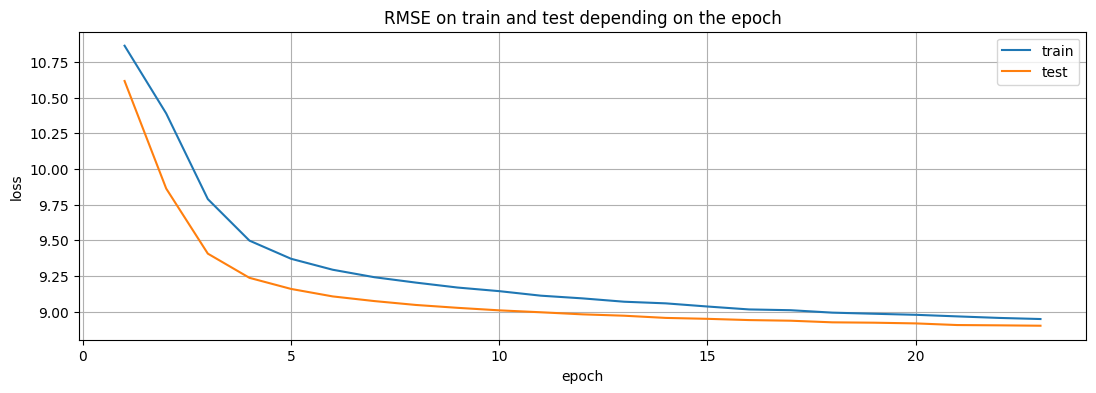

RMSE train: 8.948820739515247
RMSE test: 8.901924308195055
23


'Best RMSE on test: 8.901924308195055'

In [ ]:
set_random_seed(42)
epochs = 23
train(model_sgd, optimizer_sgd, criterion, train_loader, test_loader)

In [ ]:
# эксперимент второй: batch size = 256
set_random_seed(42)

train_set = MyDataset(X_train2, y_train)
test_set = MyDataset(X_test2, y_test)
test_loader = DataLoader(test_set, batch_size=32)
train_loader_256 = DataLoader(train_set, shuffle=True, batch_size=256)

model_256 = nn.Sequential(
    nn.Linear(
        90, 50
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        50, 30
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
        30, 10
    ),
    nn.ReLU(),
    nn.Dropout(
            0.1
    ),
    nn.Linear(
         10, 1
    )).to(device)

optimizer_256 = torch.optim.Adam(model_256.parameters(), lr=0.01, weight_decay=0)
criterion = nn.MSELoss()

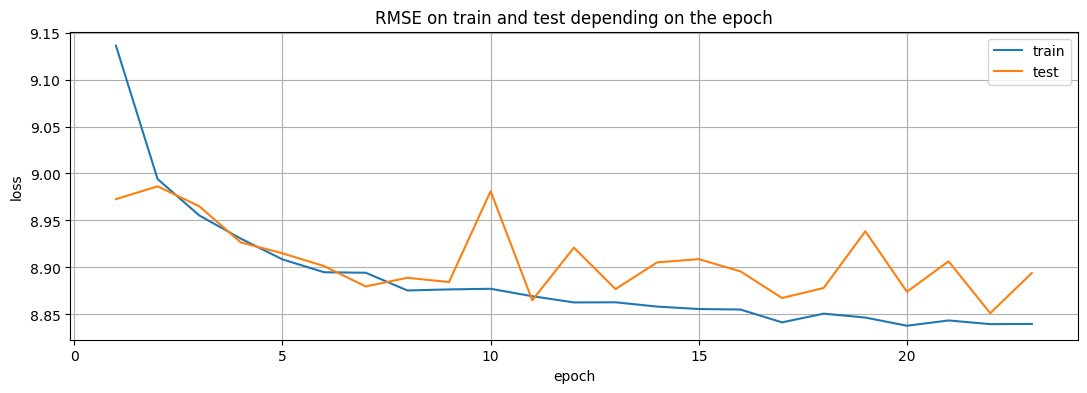

RMSE train: 8.839867463871103
RMSE test: 8.894076204291451
23


'Best RMSE on test: 8.894076204291451'

In [ ]:
set_random_seed(42)
epochs = 23
train(model_256, optimizer_256, criterion, train_loader_256, test_loader)

In [ ]:
# эксперимент третий: два линеар слоя
set_random_seed(42)

train_set = MyDataset(X_train2, y_train)
train_loader = DataLoader(train_set, shuffle=True, batch_size=1000)
test_set = MyDataset(X_test2, y_test)
test_loader = DataLoader(test_set, batch_size=32)

model_without_drop = nn.Sequential(
    nn.Linear(
        90, 50
    ),
    nn.ReLU(),
    nn.Linear(
        50, 30
    ),
    nn.ReLU(),
    nn.Linear(
        30, 10
    ),
    nn.ReLU(),
    nn.Linear(
         10, 1
    )).to(device)
optimizer_without_drop = torch.optim.Adam(model_without_drop.parameters(), lr=0.01, weight_decay=0)
criterion = nn.MSELoss()

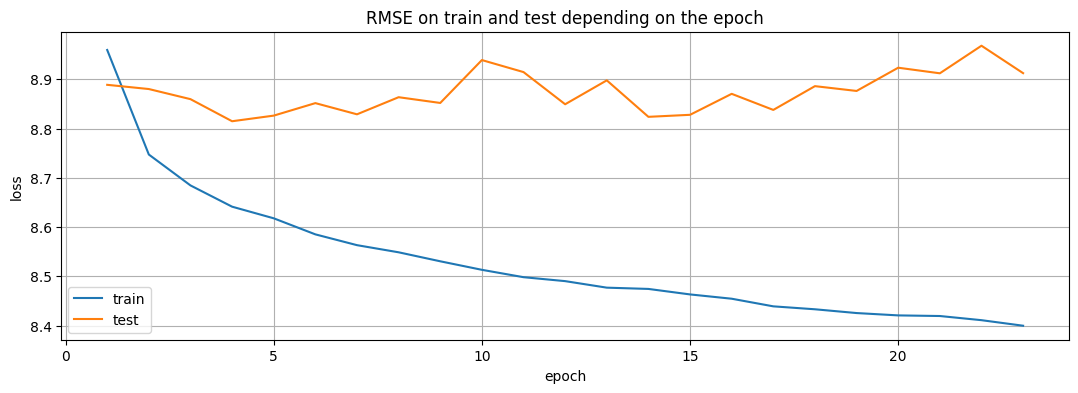

RMSE train: 8.399910728143777
RMSE test: 8.91232051334248
23


'Best RMSE on test: 8.91232051334248'

In [ ]:
set_random_seed(42)
epochs=23
train(model_without_drop, optimizer_without_drop, criterion, train_loader, test_loader)

Как видно, во всех экспериментах с лоссом на тесте все хуже.


## Задание 4. (10 баллов)

А теперь давайте попробуем решить задачу классификации на тех же данных!

Протестируйте два варианта:

1. Cчитайте каждый год, представленный в таблице, за отдельный класс

2. Разбейте года на 10 бинов и решайте задачу классификации для 10 классов

Добавьте в test подсчет метрик: accuracy, precision, recall (можете выбрать micro или macro усреднение, как посчитаете нужным).

Что можно сказать о полученных моделях? Почему результаты вышли такими? Напишите небольшой анализ того, что было проделано, чем модели классификации отличаются от задачи регрессии и друг друга?

In [ ]:
from sklearn.metrics import recall_score, precision_score

In [ ]:
y_train_class = np.digitize(y_train.numpy(), y_train.unique().numpy()) - 1
y_test_class = np.digitize(y_test.numpy(), y_train.unique().numpy()) - 1

In [ ]:
y_train_class = torch.from_numpy(y_train_class)
y_test_class = torch.from_numpy(y_test_class)

In [ ]:
train_set_class = MyDataset(X_train2, y_train_class)
train_loader_class = DataLoader(train_set_class, shuffle=True, batch_size=1000)

test_set_class = MyDataset(X_test2, y_test_class)
test_loader_class = DataLoader(test_set_class, shuffle=True, batch_size=X_test2.shape[0])

In [ ]:
# модель, где каждый класс - один год
set_random_seed(42)
model_class = nn.Sequential(
    nn.Linear(
        90, 70
    ),
    nn.Dropout(
            0.1
    ),
    nn.ReLU(),
    nn.Linear(
        70, 60
    ),
    nn.ReLU(),
    nn.Linear(
        60, 50
    ),
    nn.ReLU(),
    nn.Linear(
        50, 89
    )).to(device)
optimizer_class = torch.optim.Adam(model_class.parameters(), lr=0.001, weight_decay=0)
criterion_class = nn.CrossEntropyLoss()

In [ ]:
def train_classification(model, optimizer, criterion, train_loader):
    """
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """
    for epoch in range(1, epochs + 1):
        model.train()

        for batch in train_loader:
            x_train = batch['sample'].clone().to(device)
            y_train = batch['target'].clone().to(device).long()

            optimizer.zero_grad()
            logits = model(x_train)
            loss = criterion(logits, y_train)
            loss.backward()
            optimizer.step()

In [ ]:
def test_classification(model, criterion, test_loader):
    """
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        test_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """
    predicts = model(next(iter(test_loader))['sample']).squeeze().argmax(dim=1)
    y_true_test = next(iter(test_loader))['target']
    accuracy = (predicts == y_true_test).sum() / len(y_true_test)
    precision = precision_score(y_true_test, predicts, average='macro', zero_division=np.nan)
    recall = recall_score(y_true_test, predicts, average='macro', zero_division=np.nan)

    return predicts, accuracy, precision, recall

In [ ]:
assert test_classification(model_class, criterion_class, test_loader_class)[0].shape[0] == y_test.shape[0]

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
set_random_seed(42)
epochs = 30
train_classification(model_class, optimizer_class, criterion_class, train_loader_class)

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
y_pred_class, accuracy, precision, recall = test_classification(model_class, criterion_class, test_loader_class)

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
print(f'Accuracy on test: {accuracy}')
print(f'Precision on test: {precision}')
print(f'Racall on test: {recall}')

Accuracy on test: 0.0545225627720356
Precision on test: 0.01685724484945094
Racall on test: 0.01250110699080017


In [ ]:
# далее делим года на 10 бинов по квантилям (чтобы были сбалансированны классы)
y_train_class_bin = np.digitize(y_train.numpy(), np.quantile(y_train.numpy(), np.linspace(0, 1, 10))) - 1

In [ ]:
y_test_class_bin = np.digitize(y_test.numpy(), np.quantile(y_train.numpy(), np.linspace(0, 1, 10))) - 1

In [ ]:
y_train_class_bin = torch.from_numpy(y_train_class_bin)
y_test_class_bin = torch.from_numpy(y_test_class_bin)

In [ ]:
train_set_class_bin = MyDataset(X_train2, y_train_class_bin)
train_loader_class_bin = DataLoader(train_set_class_bin, shuffle=True, batch_size=1000)

test_set_class_bin = MyDataset(X_test2, y_test_class_bin)
test_loader_class_bin = DataLoader(train_set_class_bin, shuffle=True, batch_size=X_test2.shape[0])

In [ ]:
set_random_seed(42)
model_class2 = nn.Sequential(
    nn.Linear(
        90, 50
    ),
    nn.Dropout(
            0.1
    ),
    nn.ReLU(),
    nn.Linear(
        50, 30
    ),
    nn.ReLU(),
    nn.Linear(
        30, 20
    ),
    nn.ReLU(),
    nn.Linear(
        20, 10
    )).to(device)
optimizer_class2 = torch.optim.Adam(model_class.parameters(), lr=0.0001, weight_decay=0)
criterion_class2 = nn.CrossEntropyLoss()

In [ ]:
set_random_seed(42)
epochs = 30
train_classification(model_class2, optimizer_class2, criterion_class2, train_loader_class_bin)

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
y_pred_bin, accuracy_bin, precision_bin, recall_bin = test_classification(model_class2, criterion_class2, test_loader_class_bin)

<ipython-input-23-3c7a98664ed8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "sample": torch.tensor(self.x[idx, :], dtype=torch.float),


In [ ]:
print(f'Accuracy on test: {accuracy_bin}')
print(f'Precision on test: {precision_bin}')
print(f'Racall on test: {recall_bin}')

Accuracy on test: 0.10472593456506729
Precision on test: 0.1644981919898972
Racall on test: 0.1057584394186045


В задаче классификации по годам (89 классов) метрики ниже, чем в задаче классификации по 10 классам, потому что в первой классы сильно не сбалансированны плюс их очень много.

Задача классификации по 10 классам показывает метрики хуже, чем регрессия, так как в данном случае определение года ближе к регрессии (89 разных чисел), очень большое количество классов. Плюс, так как я делила по квантилям, в каких-то бинах оказалось очень много годов, в каких то мало, что может быть не очень хорошо, тк не обязательно годы
в одном бине могут быть схожи хоть по каким-нибудь признакам, поэтому задача классификации может справляться хуже (регрессия индивидуально подходит к каждому значению года).

Если использовать разделение на классы не по квантилям, а подряд идущими годами (то есть было бы 10 классов по 8-9 годов), опять же возникла бы проблема несбалансированности классов, причем существенная, так как у некоторых годов наблюдений лишь единицы. Поэтому годы, у которых мало наблюдений, скорее всего не определялись бы вовсе.

In [ ]:
df.loc[:, 0].value_counts()[-20:] # некоторых лет очень мало

,count
0,
1939,35
1931,35
1941,32
1945,30
1946,29
1934,29
1937,28
1936,25
1942,24


In [ ]:
df.loc[:, 0].value_counts()[:20] # а некоторых в тысячи и десятки тысяч раз больше

,count
0,
2007,39404
2006,37534
2005,34952
2008,34760
2009,31038
2004,29607
2003,27382
2002,23451
2001,21590
